In [ ]:
!pip install kmodes
!pip install openml

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

# kmodes library
from kmodes.kmodes import KModes
from kmodes.kprototypes import KPrototypes

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

In [4]:
# Fetch the dataset from OpenML
adult_data = fetch_openml(name='adult', version=1, as_frame=True)
df = adult_data.frame

# Check columns
print("Original columns:", df.columns.tolist())

# Drop rows with missing or invalid values indicated by '?'
# Many columns in 'Adult' have '?' for missing, e.g. 'workclass', 'occupation', etc.
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)

# Drop the target column "class" (<=50K or >50K) because we are doing unsupervised clustering
df.drop(columns=["class"], inplace=True)

# Let's do a random sample of 3000 rows for the demonstration
df = df.sample(n=3000, random_state=42).reset_index(drop=True)

print(f"Data shape after cleaning & sampling: {df.shape}")
df.head(5)

Original columns: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capitalgain', 'capitalloss', 'hoursperweek', 'native-country', 'class']
Data shape after cleaning & sampling: (3000, 14)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capitalgain,capitalloss,hoursperweek,native-country
0,1,Private,319768,Masters,14,Married-civ-spouse,Sales,Husband,White,Male,0,0,2,France
1,4,Private,120067,9th,5,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,2,United-States
2,2,Private,211517,Some-college,10,Never-married,Adm-clerical,Not-in-family,White,Male,0,2,2,United-States
3,1,State-gov,210866,HS-grad,9,Married-civ-spouse,Other-service,Husband,White,Male,0,0,2,United-States
4,2,Private,320811,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,2,United-States


In [5]:
numeric_cols = ["age", "education-num", "hoursperweek", "capitalgain", "capitalloss"]
cat_cols = ["workclass", "marital-status", "occupation", "sex"]

# Filter the DataFrame to these columns only
df = df[numeric_cols + cat_cols]

print("Final columns used:\n", df.columns.tolist())
print("Data info:")
df.info()

Final columns used:
 ['age', 'education-num', 'hoursperweek', 'capitalgain', 'capitalloss', 'workclass', 'marital-status', 'occupation', 'sex']
Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             3000 non-null   category
 1   education-num   3000 non-null   int64   
 2   hoursperweek    3000 non-null   category
 3   capitalgain     3000 non-null   category
 4   capitalloss     3000 non-null   category
 5   workclass       3000 non-null   category
 6   marital-status  3000 non-null   category
 7   occupation      3000 non-null   category
 8   sex             3000 non-null   category
dtypes: category(8), int64(1)
memory usage: 49.3 KB


In [6]:
df_original = df.copy()
df_scaled = df.copy()

# Scale numeric columns in df_scaled
scaler = StandardScaler()
df_scaled[numeric_cols] = scaler.fit_transform(df_scaled[numeric_cols])

print("Sample of unscaled numeric features:\n", df_original[numeric_cols].head(3))
print("\nSample of scaled numeric features:\n", df_scaled[numeric_cols].head(3))

Sample of unscaled numeric features:
   age  education-num hoursperweek capitalgain capitalloss
0   1             14            2           0           0
1   4              5            2           0           0
2   2             10            2           0           2

Sample of scaled numeric features:
         age  education-num  hoursperweek  capitalgain  capitalloss
0 -0.602207       1.489094      0.030858    -0.285294    -0.216255
1  1.782247      -1.984387      0.030858    -0.285294    -0.216255
2  0.192611      -0.054675      0.030858    -0.285294     3.119303


In [7]:
def get_silhouette(data, labels):
    if len(set(labels)) > 1 and len(set(labels)) < len(labels):
        return silhouette_score(data, labels)
    else:
        return -1  # invalid silhouette if all points in the same cluster

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

def plot_clusters_tsne_2d(data, labels, title="t-SNE (2D)", sample_size=1000, random_state=42):
    """
    data: array-like, shape (n_samples, n_features)
        The high-dimensional data you want to visualize (numeric).
    labels: array-like, shape (n_samples,)
        Cluster labels for coloring points.
    title: str
        Plot title.
    sample_size: int
        How many data points to sample for the plot (avoids heavy computation or clutter).
    random_state: int
        Random seed for reproducibility.
    """
    # 1) Sample data for plotting if it's large
    n = len(data)
    if n > sample_size:
        idx = np.random.choice(n, sample_size, replace=False)
        data_sample = data[idx]
        labels_sample = labels[idx]
    else:
        data_sample = data
        labels_sample = labels

    # 2) Fit t-SNE in 2 dimensions
    tsne = TSNE(n_components=2, random_state=random_state)
    coords = tsne.fit_transform(data_sample)

    # 3) Plot
    plt.figure(figsize=(7, 6))
    sns.scatterplot(x=coords[:,0], y=coords[:,1], hue=labels_sample, palette='Set2')
    plt.title(title)
    plt.legend(title="Cluster", loc='best')
    plt.show()

K-Means on numeric-only (scaled):
  k=2, silhouette=0.538
  k=3, silhouette=0.227
  k=4, silhouette=0.271
  k=5, silhouette=0.292

Best k=2 with silhouette=0.538


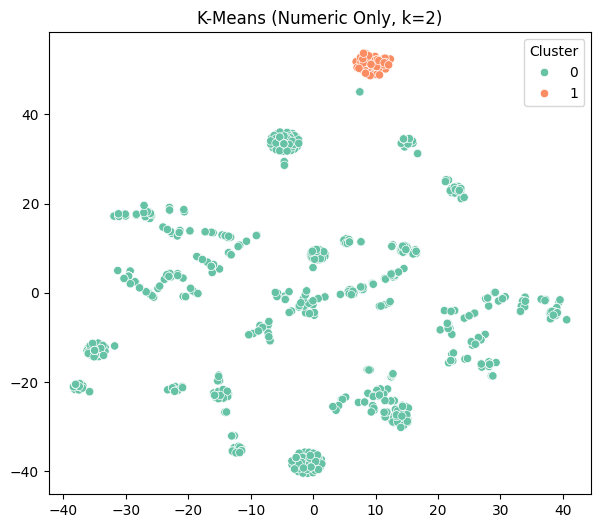

In [10]:
data_kmeans_num = df_scaled[numeric_cols].values  # only numeric columns (scaled)

best_k = None
best_score = -1

print("K-Means on numeric-only (scaled):")
for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(data_kmeans_num)
    labels_km = km.labels_
    score = get_silhouette(data_kmeans_num, labels_km)
    print(f"  k={k}, silhouette={score:.3f}")
    if score > best_score:
        best_score = score
        best_k = k

print(f"\nBest k={best_k} with silhouette={best_score:.3f}")

# Fit final model
km_final = KMeans(n_clusters=best_k, n_init=10, random_state=42)
km_final.fit(data_kmeans_num)
labels_km_final = km_final.labels_

plot_clusters_tsne_2d(data_kmeans_num, labels_km_final, f"K-Means (Numeric Only, k={best_k})")

In [12]:
df_kmodes_cat = df[cat_cols].copy()

# Ordinal encode
ord_enc = OrdinalEncoder()
cat_ordinal = ord_enc.fit_transform(df_kmodes_cat)

cat_ordinal_df = pd.DataFrame(cat_ordinal, columns=cat_cols)

K-Modes on categorical columns only:
  k=2, silhouette=0.088
  k=3, silhouette=0.022
  k=4, silhouette=0.015
  k=5, silhouette=-0.040

Best K for K-Modes: 2, silhouette=0.088


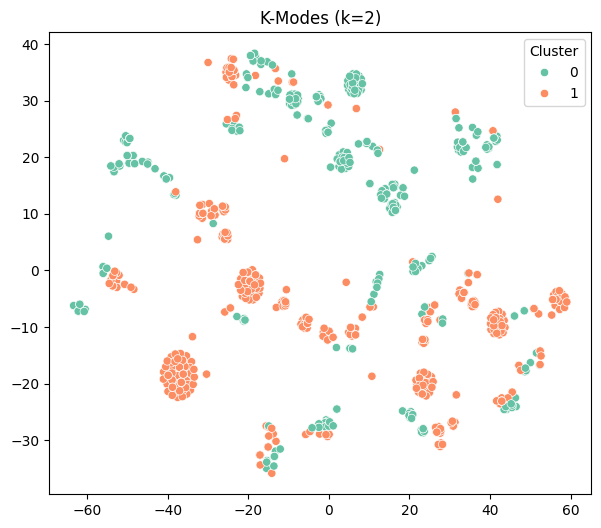

In [17]:
best_k_kmodes = None
best_score_kmodes = -1

print("K-Modes on categorical columns only:")
for k in [2, 3, 4, 5]:
    kmodes_model = KModes(n_clusters=k, n_init=5, random_state=42)
    labels_kmodes = kmodes_model.fit_predict(df_kmodes_cat)  # raw categorical data

    # Silhouette: approximate by using the ordinal-encoded data
    score = get_silhouette(cat_ordinal_df, labels_kmodes)
    print(f"  k={k}, silhouette={score:.3f}")
    if score > best_score_kmodes:
        best_score_kmodes = score
        best_k_kmodes = k

print(f"\nBest K for K-Modes: {best_k_kmodes}, silhouette={best_score_kmodes:.3f}")

# Final model
kmodes_model = KModes(n_clusters=best_k_kmodes, n_init=5, random_state=42)
labels_kmodes_final = kmodes_model.fit_predict(df_kmodes_cat)

# For plotting, we rely on the ordinal-encoded data for 2D projection
plot_clusters_tsne_2d(cat_ordinal_df.values, labels_kmodes_final,
                 title=f"K-Modes (k={best_k_kmodes})", sample_size=1000)

K-Prototypes (mixed):
  k=2, gamma=0.5, silhouette=0.171
  k=2, gamma=1, silhouette=0.173
  k=2, gamma=2, silhouette=0.174
  k=3, gamma=0.5, silhouette=0.149
  k=3, gamma=1, silhouette=0.149
  k=3, gamma=2, silhouette=0.149
  k=4, gamma=0.5, silhouette=0.112
  k=4, gamma=1, silhouette=0.114
  k=4, gamma=2, silhouette=0.111

Best K-Prototypes -> k=2, gamma=2, silhouette=0.174


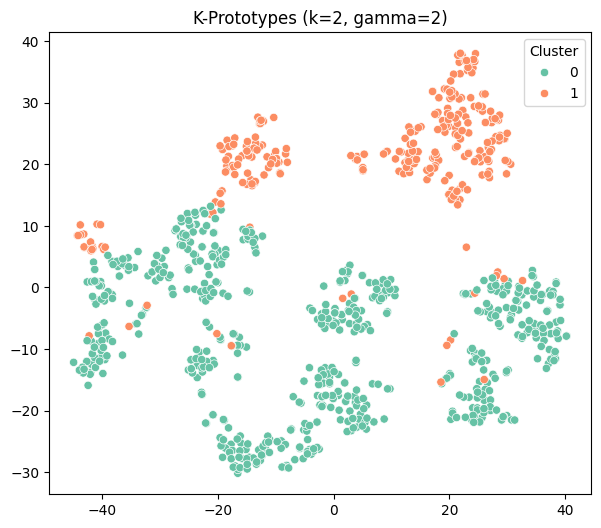

In [18]:
df_kproto = df.copy()

# Convert numeric columns to float, categorical to string
for col in numeric_cols:
    df_kproto[col] = df_kproto[col].astype(float)
for col in cat_cols:
    df_kproto[col] = df_kproto[col].astype(str)

matrix_kproto = df_kproto.values

# Indices of categorical columns
cat_col_idx = [df.columns.get_loc(c) for c in cat_cols]

best_k_kproto = None
best_gamma = None
best_score_kproto = -1

print("K-Prototypes (mixed):")
for k in [2, 3, 4]:
    for gamma_val in [0.5, 1, 2]:
        kproto = KPrototypes(n_clusters=k,  gamma=gamma_val, random_state=42, n_jobs=-1)
        labels_kp = kproto.fit_predict(matrix_kproto, categorical=cat_col_idx)

        # For silhouette approximation, we ordinal-encode the categorical columns
        # so that we can have a single numeric array:
        temp_ord = df.copy()
        temp_ord[cat_cols] = OrdinalEncoder().fit_transform(temp_ord[cat_cols])
        numeric_matrix = temp_ord.values

        score = get_silhouette(numeric_matrix, labels_kp)
        print(f"  k={k}, gamma={gamma_val}, silhouette={score:.3f}")
        if score > best_score_kproto:
            best_score_kproto = score
            best_k_kproto = k
            best_gamma = gamma_val

print(f"\nBest K-Prototypes -> k={best_k_kproto}, gamma={best_gamma}, silhouette={best_score_kproto:.3f}")

# Final model
kproto_best = KPrototypes(n_clusters=best_k_kproto, gamma=best_gamma, random_state=42, n_jobs=-1)
labels_kproto_best = kproto_best.fit_predict(matrix_kproto, categorical=cat_col_idx)

# Plot
temp_ord = df.copy()
temp_ord[cat_cols] = OrdinalEncoder().fit_transform(temp_ord[cat_cols])
numeric_matrix_final = temp_ord.values

plot_clusters_tsne_2d(numeric_matrix_final, labels_kproto_best,
                 title=f"K-Prototypes (k={best_k_kproto}, gamma={best_gamma})",
                 sample_size=1000)

Hierarchical Clustering (Agglomerative) on scaled numeric:
  k=2, silhouette=0.504
  k=3, silhouette=0.519
  k=4, silhouette=0.210
  k=5, silhouette=0.247

Best Agglomerative -> k=3, silhouette=0.519


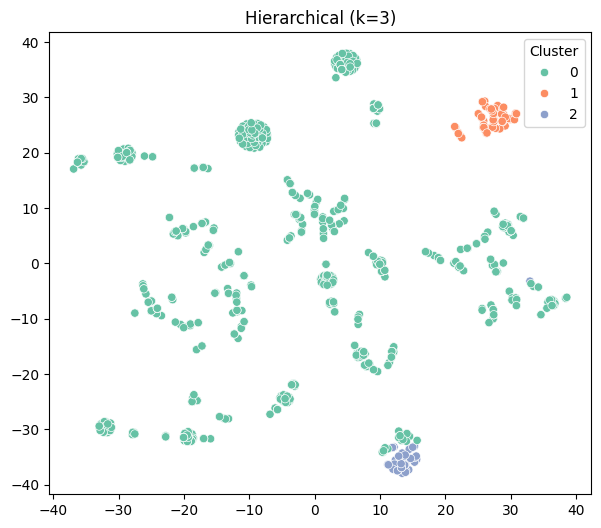

In [15]:
data_hier = df_scaled[numeric_cols].values

best_hier_k = None
best_hier_score = -1

print("Hierarchical Clustering (Agglomerative) on scaled numeric:")
for k in [2, 3, 4, 5]:
    hier = AgglomerativeClustering(n_clusters=k)
    labels_hier = hier.fit_predict(data_hier)
    score = get_silhouette(data_hier, labels_hier)
    print(f"  k={k}, silhouette={score:.3f}")
    if score > best_hier_score:
        best_hier_score = score
        best_hier_k = k

print(f"\nBest Agglomerative -> k={best_hier_k}, silhouette={best_hier_score:.3f}")

# Final model
hier_final = AgglomerativeClustering(n_clusters=best_hier_k)
labels_hier_final = hier_final.fit_predict(data_hier)
plot_clusters_tsne_2d(data_hier, labels_hier_final,
                 title=f"Hierarchical (k={best_hier_k})")

DBSCAN on scaled numeric:
  eps=0.5, min_samples=5, #clusters=57, silhouette=0.201
  eps=0.5, min_samples=10, #clusters=27, silhouette=0.184
  eps=0.5, min_samples=20, #clusters=19, silhouette=0.169
  eps=1.0, min_samples=5, #clusters=26, silhouette=0.140
  eps=1.0, min_samples=10, #clusters=16, silhouette=0.134
  eps=1.0, min_samples=20, #clusters=8, silhouette=0.095
  eps=1.5, min_samples=5, #clusters=6, silhouette=0.106
  eps=1.5, min_samples=10, #clusters=6, silhouette=0.105
  eps=1.5, min_samples=20, #clusters=4, silhouette=0.370

Best DBSCAN -> eps=1.5, min_samples=20, silhouette=0.370


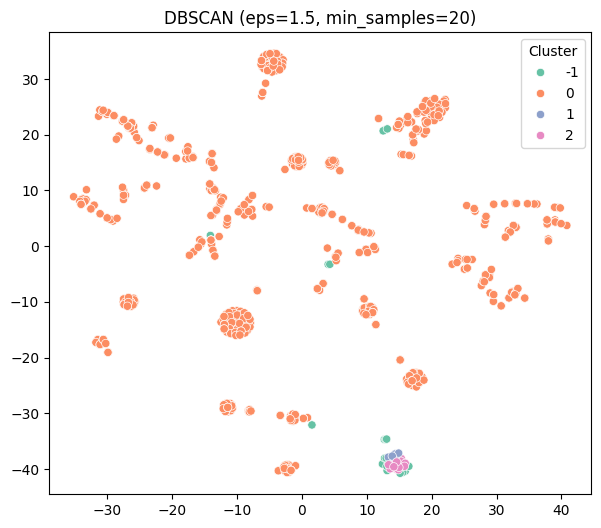

In [16]:
data_dbscan = df_scaled[numeric_cols].values

best_dbscan_score = -1
best_dbscan_params = (None, None)

print("DBSCAN on scaled numeric:")
for eps_val in [0.5, 1.0, 1.5]:
    for min_samp in [5, 10, 20]:
        dbscan = DBSCAN(eps=eps_val, min_samples=min_samp)
        labels_db = dbscan.fit_predict(data_dbscan)
        score = get_silhouette(data_dbscan, labels_db)
        # If DBSCAN lumps everything into one cluster or noise, silhouette is meaningless
        print(f"  eps={eps_val}, min_samples={min_samp}, #clusters={len(set(labels_db))}, silhouette={score:.3f}")
        if score > best_dbscan_score:
            best_dbscan_score = score
            best_dbscan_params = (eps_val, min_samp)

eps_best, ms_best = best_dbscan_params
print(f"\nBest DBSCAN -> eps={eps_best}, min_samples={ms_best}, silhouette={best_dbscan_score:.3f}")

dbscan_final = DBSCAN(eps=eps_best, min_samples=ms_best)
labels_dbscan_final = dbscan_final.fit_predict(data_dbscan)

plot_clusters_tsne_2d(data_dbscan, labels_dbscan_final,
                 title=f"DBSCAN (eps={eps_best}, min_samples={ms_best})")